<table>
    <tr>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">
            <FONT COLOR="blue">Entregable 3<br>K-means y PCA<br>Métodos de Ensamble</FONT></h1>
        </td>
        <td>
            <p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina</p>
            <p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p>
            <p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p>
        </td>
    </tr>
</table>

**Integrantes:**
- Nombre 1
- Nombre 2
- Nombre 3

# <FONT COLOR="Purple"> 1. PCA </FONT>

## 1.1 Librerías

In [ ]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster       import KMeans
from sklearn.metrics       import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings("ignore")

## 1.2 Cargar y explorar los datos

In [ ]:
paises = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_paises.csv")
paises.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [ ]:
paises.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
paises.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
# Verificar valores faltantes
paises.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


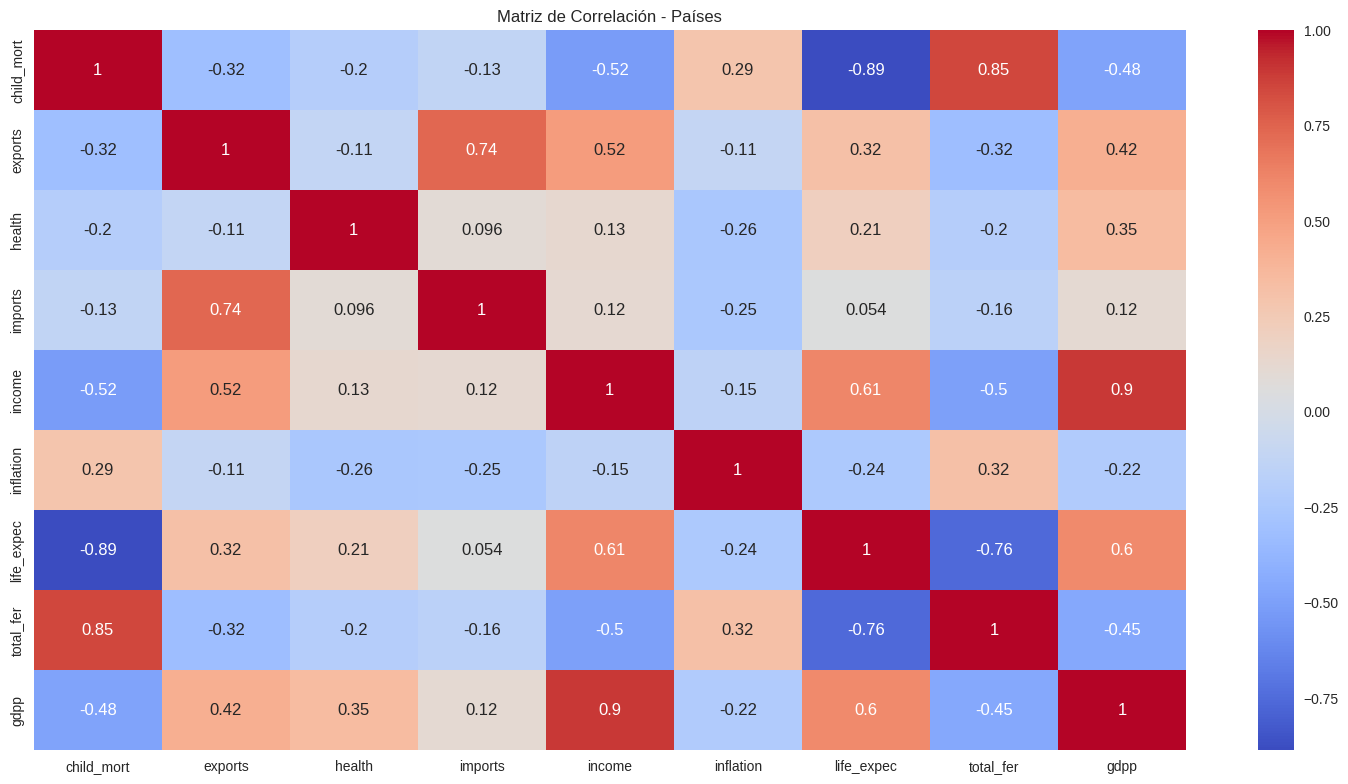

In [ ]:
# Mapa de calor de correlaciones .
corr = paises.select_dtypes(include="number").corr()
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.title("Matriz de Correlación - Países")
plt.tight_layout()
plt.show()

## 1.3 Análisis de PCA

In [ ]:
# Separar columna país y variables numéricas
paises_num    = paises.select_dtypes(include="number").dropna()
nombres_paises = paises.loc[paises_num.index, paises.columns[0]]

# Estandarizar .
paises_std = StandardScaler().fit_transform(paises_num)

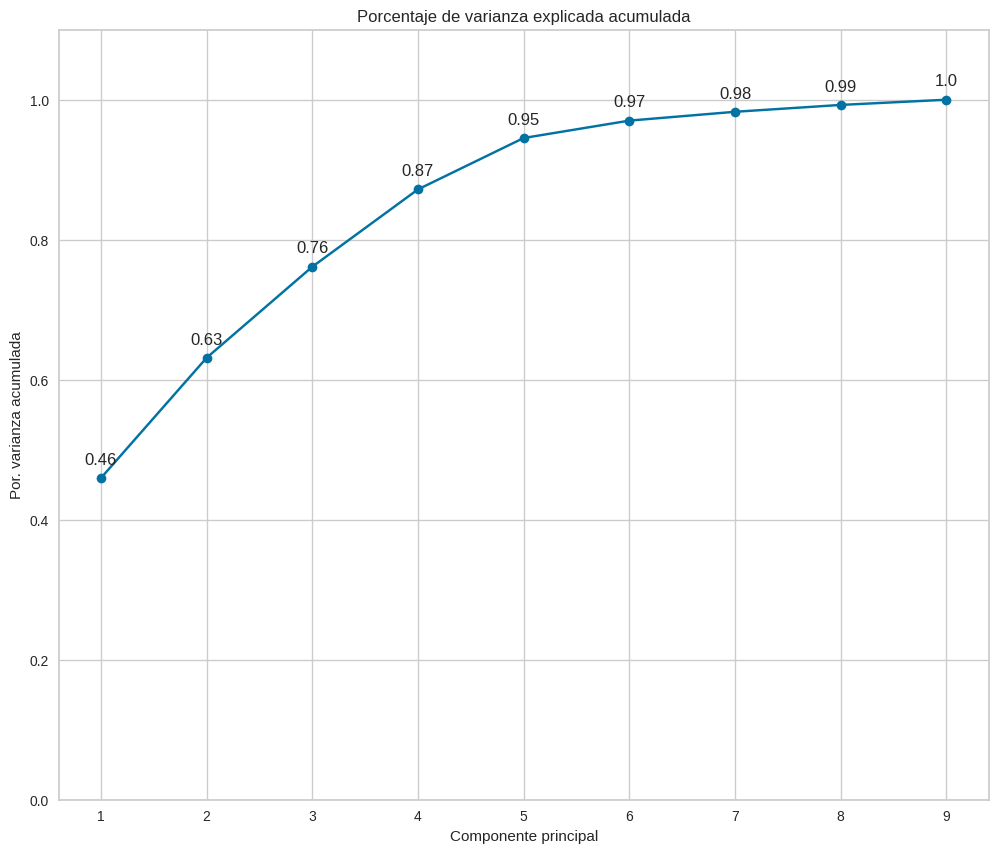

In [ ]:
# Varianza explicada acumulada .
pca_full = PCA()
pca_full.fit(paises_std)

prop_varianza_acum = pca_full.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10))
ax.plot(
    np.arange(len(prop_varianza_acum)) + 1,
    prop_varianza_acum,
    marker="o"
)

for x, y in zip(np.arange(len(prop_varianza_acum)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca_full.n_components_) + 1)
ax.set_title("Porcentaje de varianza explicada acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Por. varianza acumulada")
plt.show()

In [ ]:
# PCA con 2 componentes .
pca = PCA(n_components=2)
pca.fit(paises_std)
pca_proj = pca.transform(paises_std)

print("Varianza explicada por componente:", pca.explained_variance_ratio_)
ratio = np.sum(pca.explained_variance_ratio_)
print(f"La cantidad de variabilidad retenida por las 2 primeras componentes es {ratio*100:.3f}%")

Varianza explicada por componente: [0.4595174  0.17181626]
La cantidad de variabilidad retenida por las 2 primeras componentes es 63.133%


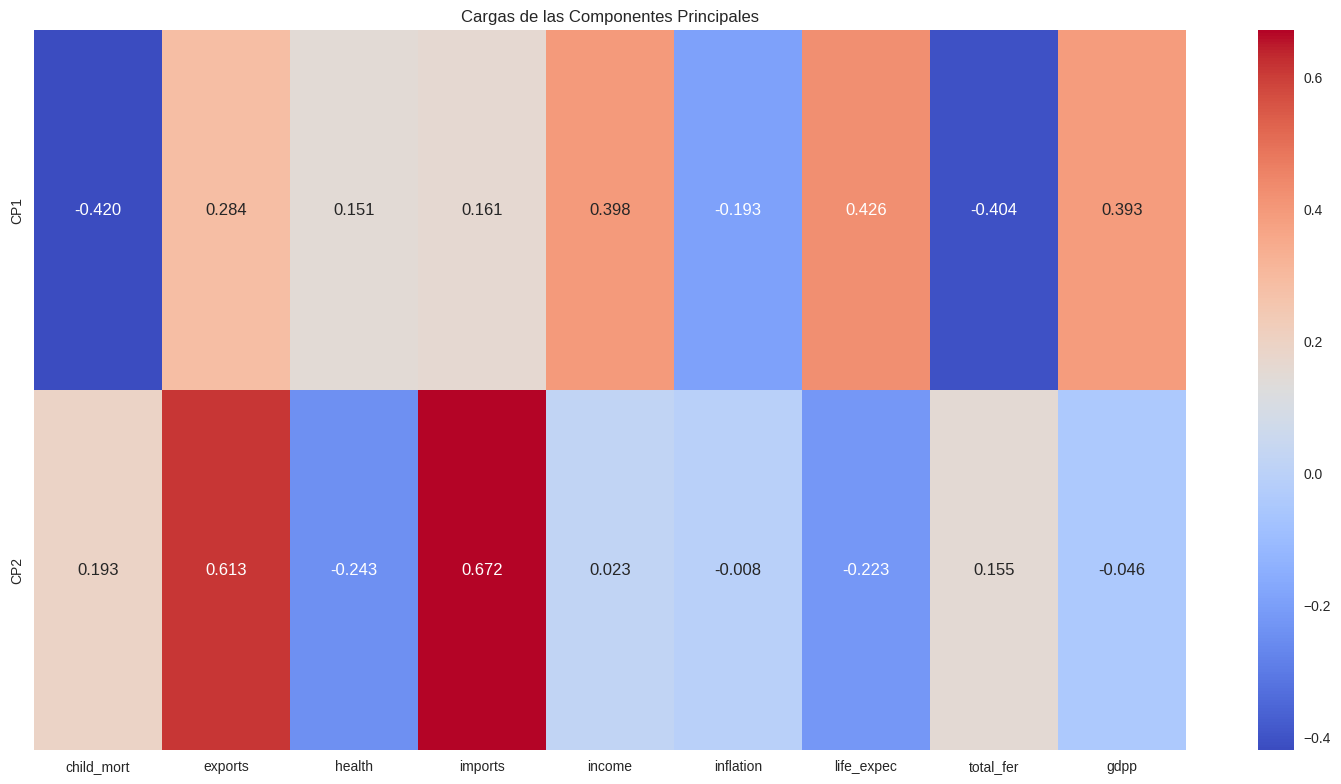

In [ ]:
# Heatmap de cargas .
sns.heatmap(pca.components_,
            xticklabels=paises_num.columns,
            yticklabels=["CP1", "CP2"],
            cmap="coolwarm",
            fmt=".3f",
            annot=True)
plt.title("Cargas de las Componentes Principales")
plt.tight_layout()
plt.show()

In [ ]:
# Proyección de países en PC1 y PC2 .
proyecciones = pd.DataFrame(pca_proj,
                            columns=["PC1", "PC2"],
                            index=paises_num.index)
proyecciones["Pais"] = nombres_paises.values

fig = px.scatter(proyecciones,
                 x="PC1",
                 y="PC2",
                 hover_name="Pais",
                 text="Pais")
fig.show()

## 1.4 Biplot

In [ ]:
!pip install pca -q

In [ ]:
from pca import pca

model_pca = pca(n_components=2, normalize=True)
out = model_pca.fit_transform(paises_num)

[04-05-2026 01:43:06] [pca.pca] [INFO] Extracting column labels from dataframe.
[04-05-2026 01:43:06] [pca.pca] [INFO] Extracting row labels from dataframe.
[04-05-2026 01:43:06] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[04-05-2026 01:43:06] [pca.pca] [INFO] The PCA reduction is performed on 9 variables (columns) of the input dataframe.
[04-05-2026 01:43:06] [pca.pca] [INFO] Fit using PCA.
[04-05-2026 01:43:06] [pca.pca] [INFO] Compute loadings and PCs.
[04-05-2026 01:43:06] [pca.pca] [INFO] Compute explained variance.
[04-05-2026 01:43:06] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[04-05-2026 01:43:06] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[04-05-2026 01:43:06] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]


[04-05-2026 01:43:06] [pca.pca] [WARNING] Parameter <label> is deprecated and will not be supported in future version.
[04-05-2026 01:43:06] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[04-05-2026 01:43:06] [scatterd.scatterd] [INFO] Create scatterplot


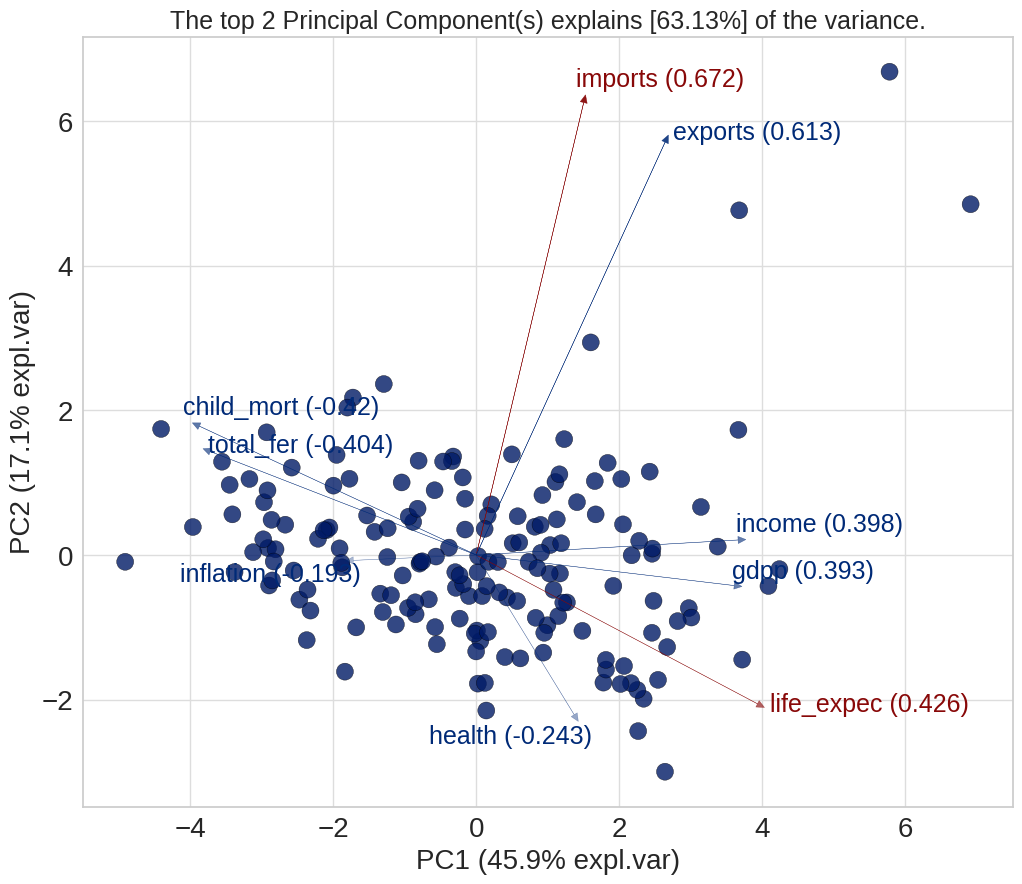

In [ ]:
# Biplot con etiquetas .
fig, ax = model_pca.biplot(label=True,
                           legend=True,
                           figsize=(12, 10))
plt.show()

[04-05-2026 01:43:08] [pca.pca] [WARNING] Parameter <label> is deprecated and will not be supported in future version.
[04-05-2026 01:43:08] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[04-05-2026 01:43:08] [scatterd.scatterd] [INFO] Create scatterplot


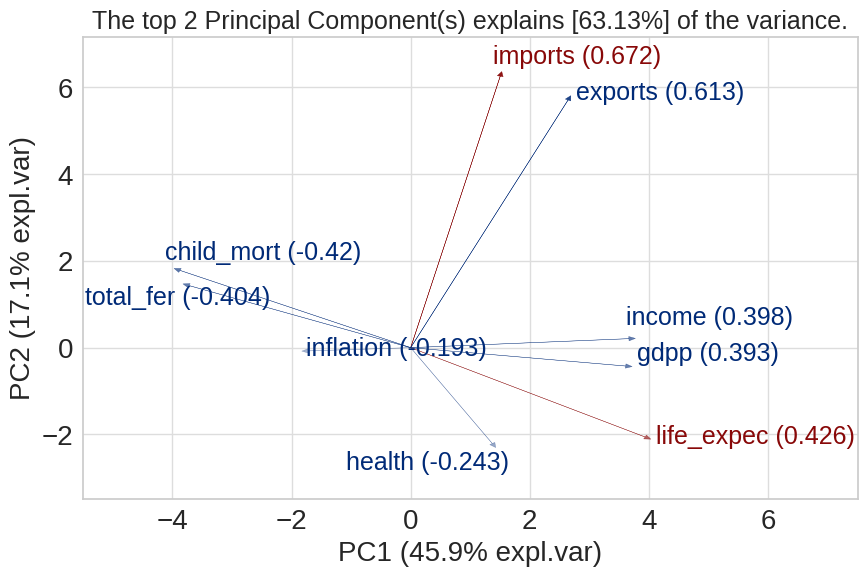

In [ ]:
# Biplot sin puntos .
fig, ax = model_pca.biplot(cmap=None,
                           label=False,
                           legend=False,
                           figsize=(10, 6))
plt.show()

## 1.5 Conclusiones PCA

> *Escriba sus conclusiones: qué componentes retienen mayor varianza, qué variables pesan más en cada componente, qué grupos de países se distinguen.*

# <FONT COLOR="Purple"> 2. K-means </FONT>

## 2.1 Método del Codo

In [ ]:
!pip install yellowbrick -q

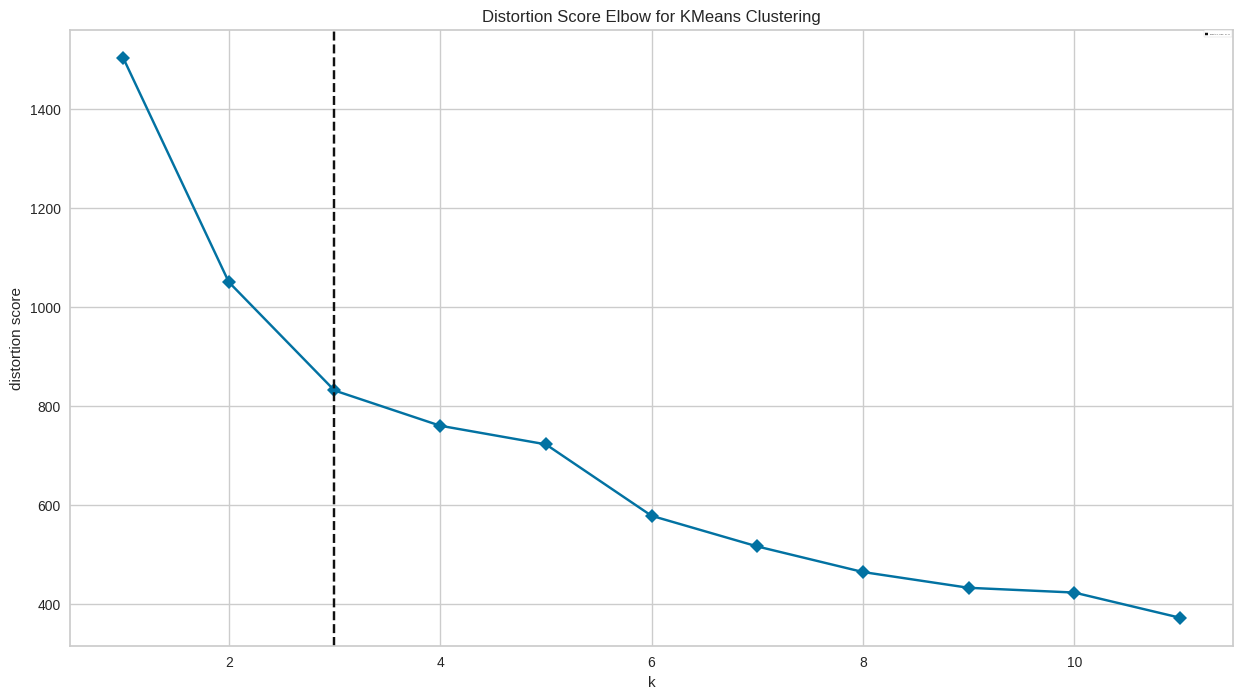

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

# Datos estandarizados del punto 1
# Método del codo con yellowbrick .
model = KMeans()
visualizer = KElbowVisualizer(model,
                              k=(1, 12),
                              timings=False)
visualizer.fit(paises_std)
visualizer.show(show=False)
plt.show()

## 2.2 Método de la Silueta

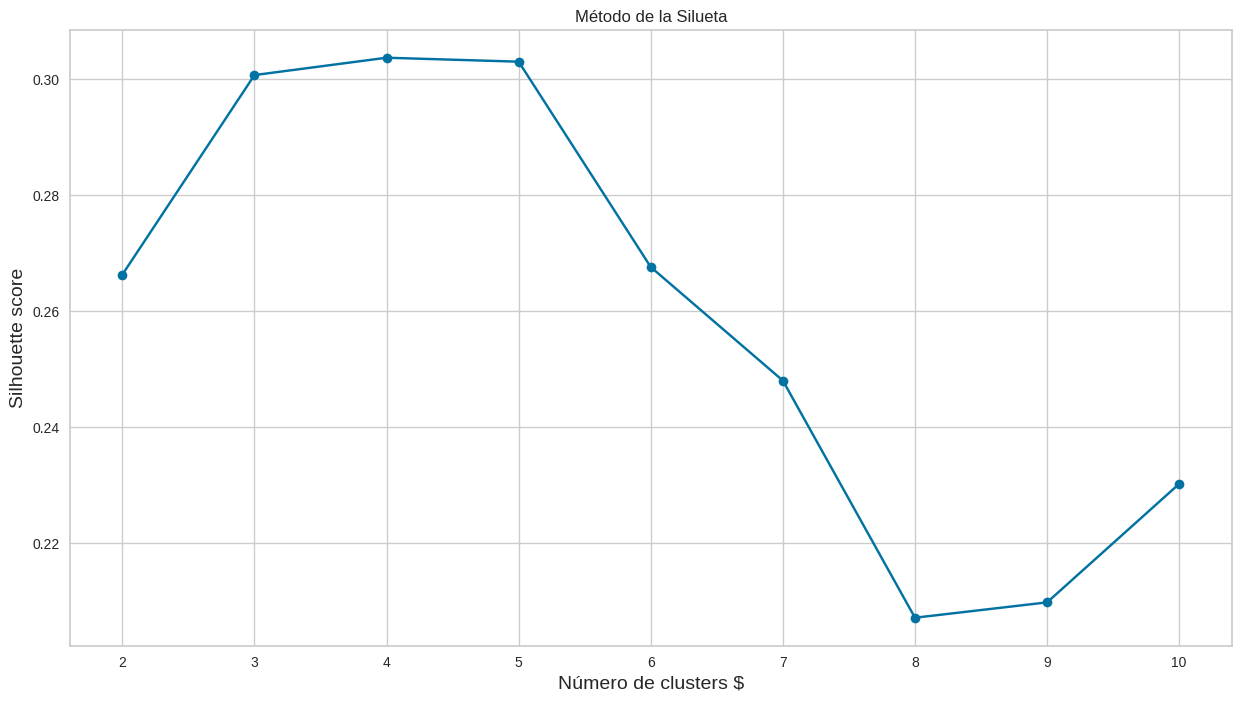

In [ ]:
# Silhouette score para cada k .
models = [KMeans(n_clusters=n, random_state=0).fit(paises_std) for n in range(2, 11)]
silhouette_scores = [silhouette_score(paises_std, model.labels_) for model in models]

plt.plot(list(range(2, 11)), silhouette_scores, "bo-")
plt.xlabel("Número de clusters $", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Método de la Silueta")
plt.show()

## 2.3 Modelo final

In [ ]:
# Ajustar k según los gráficos anteriores
k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, random_state=0)
kmeans_final.fit(paises_std)

print(kmeans_final.inertia_)
print(kmeans_final.cluster_centers_)

700.7033258497504
[[-0.84900324  4.93567278 -0.00816303  4.54805768  2.4395424  -0.50420614
   1.22682431 -1.03886271  2.44079735]
 [-0.43706491  0.02737909 -0.19090588  0.06955093 -0.20131886 -0.03918493
   0.28566125 -0.44720856 -0.31752579]
 [-0.82787747  0.16811209  0.88737767 -0.30560645  1.48891727 -0.47955552
   1.1087252  -0.75076544  1.70196967]
 [ 1.34541883 -0.45967186 -0.1895969  -0.22567743 -0.68713515  0.39226703
  -1.26429235  1.32908188 -0.60530769]]


In [ ]:
# Agregar etiquetas al dataframe
paises_cluster = paises_num.copy()
paises_cluster["cluster"] = kmeans_final.labels_
paises_cluster["Pais"]    = nombres_paises.values
paises_cluster.head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,Pais
0,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,3,Afghanistan
1,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,1,Albania
2,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,1,Algeria
3,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,3,Angola
4,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,1,Antigua and Barbuda
5,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,1,Argentina
6,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,1,Armenia
7,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,2,Australia
8,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,2,Austria
9,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,1,Azerbaijan


In [ ]:
# Media por cluster .
paises_cluster.groupby(by=["cluster"]).mean(numeric_only=True).round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
1,20.70,41.86,6.29,48.57,13275.29,7.37,73.09,2.27,7161.77
2,4.98,45.70,9.25,39.51,45762.07,2.73,80.39,1.81,44065.52
3,92.37,28.55,6.30,41.44,3937.77,11.92,59.35,4.95,1902.92


## 2.4 Boxplots por cluster

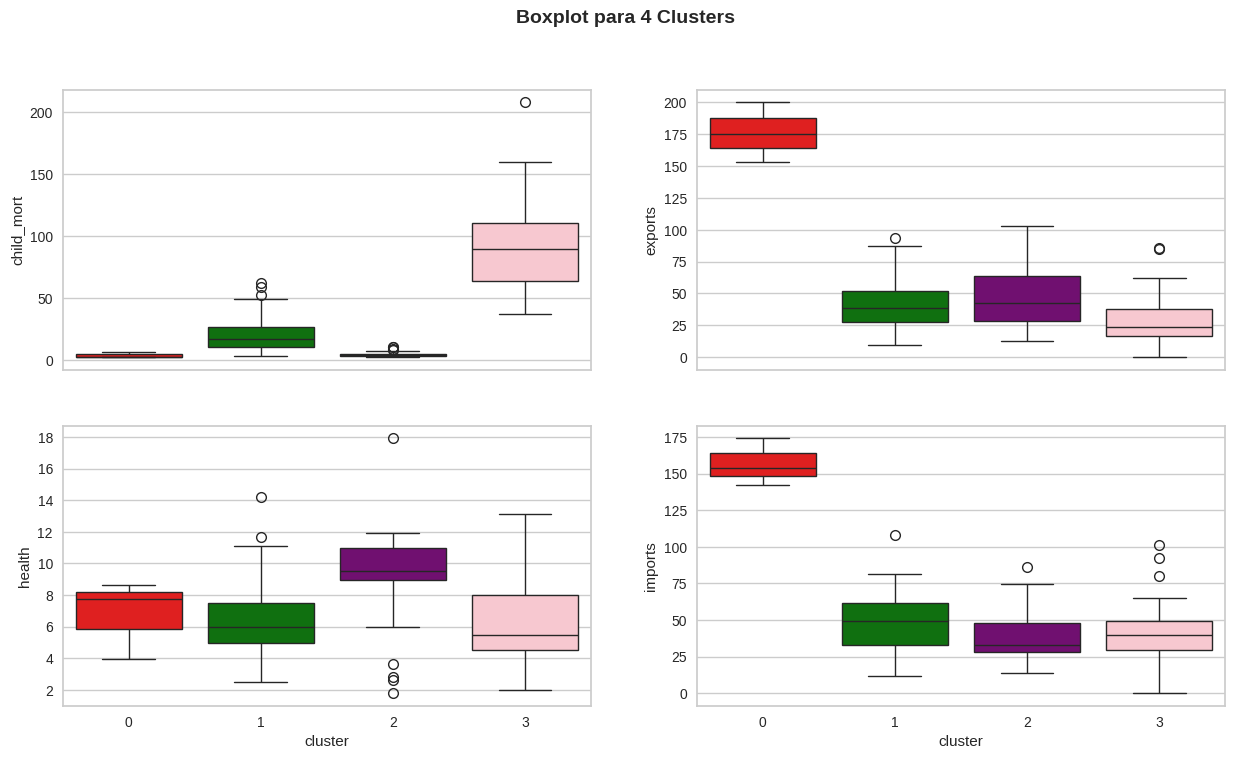

In [ ]:
# Boxplots de variables por cluster .
plt.rcParams["figure.figsize"] = (15, 8)

paises_cluster["cluster"] = paises_cluster["cluster"].astype("category")

my_colors = {"0": "red", "1": "green", "2": "purple", "3": "pink"}

variables = list(paises_num.columns[:4])
fig, axes = plt.subplots(2, 2, sharex=True)

sns.boxplot(data=paises_cluster, x="cluster", y=variables[0], palette=my_colors, ax=axes[0, 0])
sns.boxplot(data=paises_cluster, x="cluster", y=variables[1], palette=my_colors, ax=axes[0, 1])
sns.boxplot(data=paises_cluster, x="cluster", y=variables[2], palette=my_colors, ax=axes[1, 0])
sns.boxplot(data=paises_cluster, x="cluster", y=variables[3], palette=my_colors, ax=axes[1, 1])

fig.suptitle(f"Boxplot para {k_optimo} Clusters", fontsize=14, fontweight="bold")
plt.show()

## 2.5 Silhouette Plot

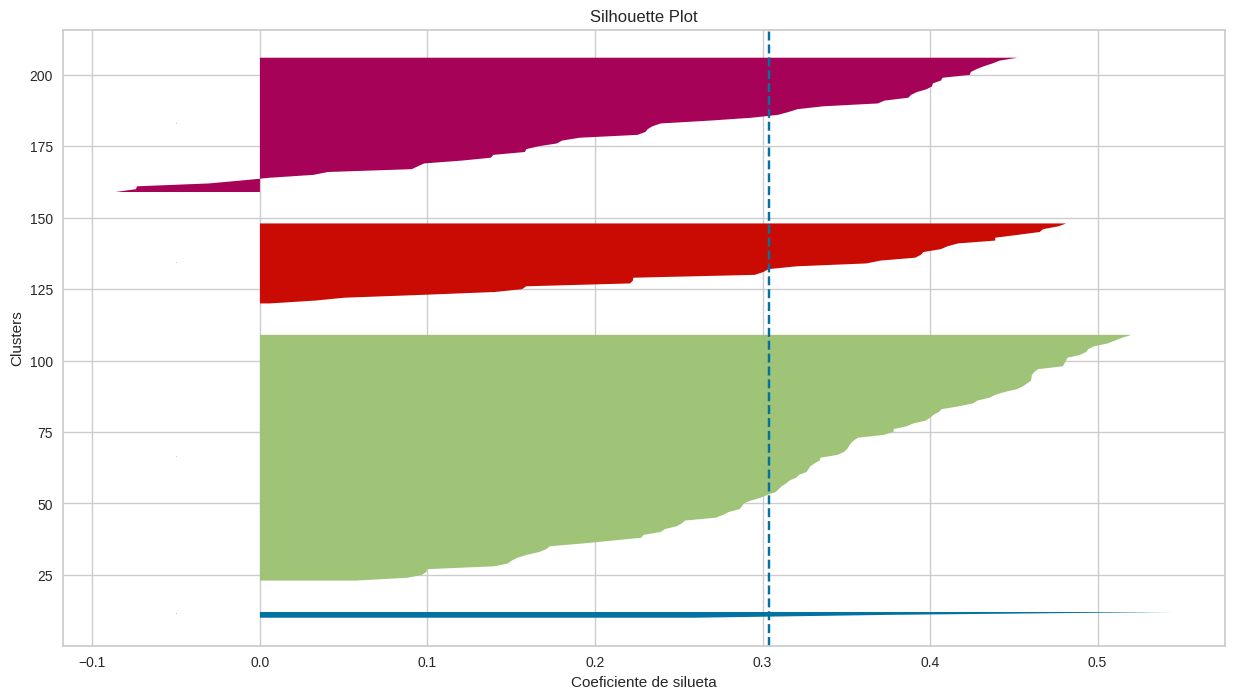

In [ ]:
# Silhouette plot .
silhouette_avg         = silhouette_score(paises_std, paises_cluster["cluster"])
sample_silhouette_values = silhouette_samples(paises_std, paises_cluster["cluster"])

k = len(np.unique(paises_cluster["cluster"]))

fig, ax = plt.subplots()
y_lower = 10
for i in range(k):
    ith_cluster_values = sample_silhouette_values[paises_cluster["cluster"] == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, linestyle="--")
ax.set_title("Silhouette Plot")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Clusters")
plt.show()

## 2.6 Clusters sobre componentes PCA

In [ ]:
# Scatter PCA coloreado por cluster .
proyecciones["cluster"] = kmeans_final.labels_.astype(str)

fig = px.scatter(proyecciones,
                 x="PC1",
                 y="PC2",
                 color="cluster",
                 hover_name="Pais",
                 text="Pais",
                 title=f"K-means (k={k_optimo}) sobre componentes PCA")
fig.show()

## 2.7 Conclusiones K-means

> *Escriba sus conclusiones: qué k eligió y por qué, cómo se caracterizan los clusters, qué países quedan agrupados y qué significado tienen.*

# <FONT COLOR="Purple"> 3. Métodos de Ensamble </FONT>

## 3.1 Librerías

In [ ]:
# Manipulación de data.frames
import pandas as pd
import numpy  as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Datos de entrenamiento y prueba
from sklearn.model_selection  import train_test_split

# Preprocesamiento
from sklearn.preprocessing    import LabelEncoder

# Modelos de ensamble (regresión)
from sklearn.ensemble         import RandomForestRegressor
from xgboost                  import XGBRegressor

# Métricas de regresión
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 3.2 Cargar y explorar los datos

In [ ]:
ventas = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_ventas.csv")
ventas.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [ ]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [ ]:
ventas.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [ ]:
# Valores faltantes
ventas.isna().sum()

,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0


In [ ]:
# Distribución de la variable objetivo con plotly .
fig = px.histogram(ventas,
                   x="Sales",
                   nbins=30,
                   title="Distribución de Ventas")
fig.show()

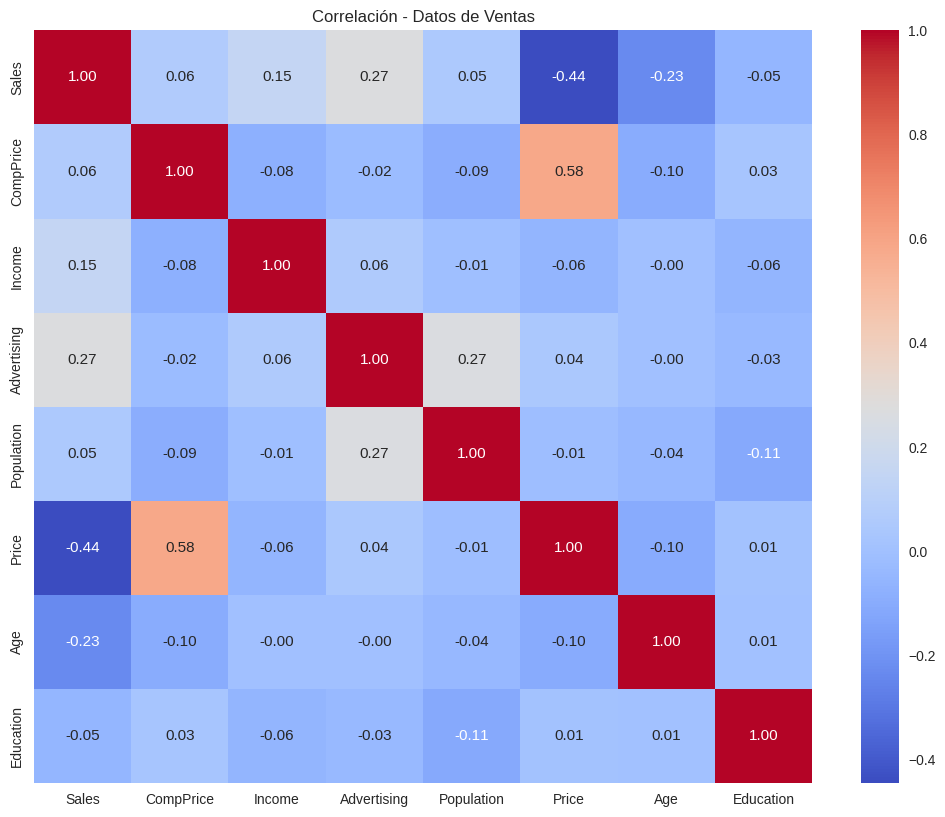

In [ ]:
# Mapa de calor de correlaciones variables numéricas
corr_v = ventas.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_v,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            annot_kws={"size": 11})
plt.title("Correlación - Datos de Ventas")
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot de Ventas por ShelveLoc .
fig = px.box(ventas,
             x="ShelveLoc",
             y="Sales",
             color="ShelveLoc",
             title="Ventas por ubicación en estante")
fig.show()

## 3.3 Preprocesamiento

In [ ]:
# Codificar variables categóricas con LabelEncoder .
ventas_enc = ventas.copy()
le         = LabelEncoder()

for col in ventas_enc.select_dtypes(include="object").columns:
    ventas_enc[col] = le.fit_transform(ventas_enc[col])

ventas_enc.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Separar predictoras y variable objetivo .
X = ventas_enc.drop("Sales", axis=1)
y = ventas_enc["Sales"]

# Conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                     y,
                                                     random_state=0,
                                                     test_size=0.3)
print("Entrenamiento:", X_train.shape, "  Prueba:", X_test.shape)

Entrenamiento: (280, 10)   Prueba: (120, 10)


## 3.4 Random Forest

In [ ]:
# Modelo Random Forest Regressor
modelo_rf = RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features="sqrt",
                bootstrap=True,
                random_state=123
)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=300, random_state=123)

In [ ]:
# Métricas Random Forest
y_pred_rf = modelo_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

=== Random Forest ===
RMSE : 1.6283
MAE  : 1.3105
R2   : 0.6056


## 3.5 XGBoost

In [ ]:
# Modelo XGBoost Regressor
modelo_xgb = XGBRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                random_state=123
)
modelo_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Métricas XGBoost
y_pred_xgb = modelo_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"MAE  : {mae_xgb:.4f}")
print(f"R2   : {r2_xgb:.4f}")

=== XGBoost ===
RMSE : 1.4263
MAE  : 1.1471
R2   : 0.6974


## 3.6 Comparación de modelos

In [ ]:
# Tabla comparativa
comparacion = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "RMSE"  : [rmse_rf,  rmse_xgb],
    "MAE"   : [mae_rf,   mae_xgb],
    "R2"    : [r2_rf,    r2_xgb]
})
print(comparacion.to_string(index=False))

       Modelo     RMSE     MAE       R2
Random Forest 1.628349 1.31050 0.605570
      XGBoost 1.426280 1.14711 0.697389


In [ ]:
# Comparación visual de métricas con plotly .
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=["RMSE (menor es mejor)",
                                    "MAE (menor es mejor)",
                                    "R2 (mayor es mejor)"])

modelos = ["Random Forest", "XGBoost"]
colores = ["steelblue", "coral"]

for col_idx, (metric, vals) in enumerate([("RMSE", [rmse_rf, rmse_xgb]),
                                           ("MAE",  [mae_rf,  mae_xgb]),
                                           ("R2",   [r2_rf,   r2_xgb])], 1):
    fig.add_trace(
        go.Bar(x=modelos, y=vals, marker_color=colores, showlegend=False),
        row=1, col=col_idx
    )

fig.update_layout(title_text="Comparación Random Forest vs XGBoost",
                  height=450, width=900)
fig.show()

## 3.7 Variables más influyentes

In [ ]:
# Importancia de variables - Random Forest .
importancia_rf = pd.DataFrame({
    "Variable"   : X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=True)

fig = px.bar(importancia_rf,
             x="Importancia",
             y="Variable",
             orientation="h",
             title="Importancia de variables - Random Forest")
fig.show()

In [ ]:
# Importancia de variables - XGBoost .
importancia_xgb = pd.DataFrame({
    "Variable"   : X.columns,
    "Importancia": modelo_xgb.feature_importances_
}).sort_values("Importancia", ascending=True)

fig = px.bar(importancia_xgb,
             x="Importancia",
             y="Variable",
             orientation="h",
             title="Importancia de variables - XGBoost")
fig.show()

## 3.8 Predicciones

In [ ]:
# Predicciones vs reales en scatter .
resultados = pd.DataFrame({
    "Real"          : y_test.values,
    "Pred_RF"       : y_pred_rf,
    "Pred_XGB"      : y_pred_xgb
})

fig = px.scatter(resultados,
                 x="Real",
                 y="Pred_RF",
                 title="Predicciones vs Reales - Random Forest")
fig.add_shape(type="line",
              x0=resultados["Real"].min(), y0=resultados["Real"].min(),
              x1=resultados["Real"].max(), y1=resultados["Real"].max(),
              line=dict(color="red", dash="dash"))
fig.show()

In [ ]:
fig = px.scatter(resultados,
                 x="Real",
                 y="Pred_XGB",
                 title="Predicciones vs Reales - XGBoost")
fig.add_shape(type="line",
              x0=resultados["Real"].min(), y0=resultados["Real"].min(),
              x1=resultados["Real"].max(), y1=resultados["Real"].max(),
              line=dict(color="red", dash="dash"))
fig.show()

## 3.9 Conclusiones Métodos de Ensamble

> *Escriba sus conclusiones: cuál modelo tuvo mejor desempeño y por qué, qué variables son las más influyentes, qué implicaciones tiene esto para la empresa.*